In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

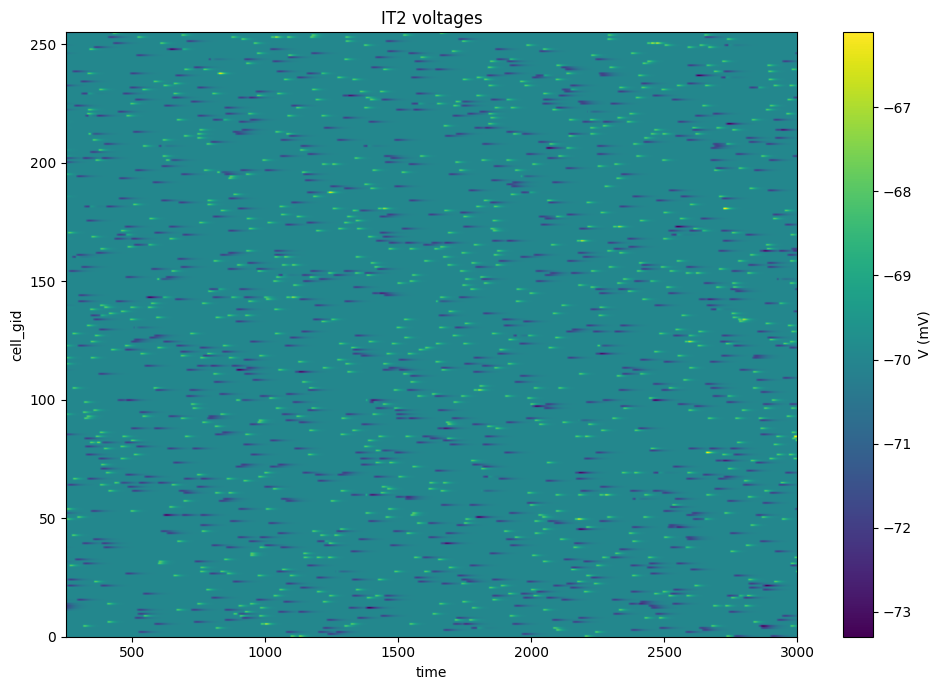

In [5]:
exp_name = 'single_rxbkg_unconn_state1_mech1'

exp_name_sub = 'exp_it2_rx_1_1_wx_1.25_5_noise_1_tx0_0_0_t_2.0_3.0_vrest_-70_trec_1'
pops_all = ['IT2']
            
#pops_all = ['IT2', 'IT3', 'ITS4', 'ITP4', 'IT5A', 'CT5A',
#            'IT5B', 'CT5B', 'PT5B', 'IT6', 'CT6']

dirpath_res = Path(
    '/ddn/niknovikov19/repo/A1_OUinp/exp_results'
    f'/{exp_name}/psp_test/{exp_name_sub}'
)

plt.figure(figsize=(10, 7))

#for p, pop_vis in enumerate(pops_all):

pop_vis = 'IT2'
fpath_in = dirpath_res / f'voltages/{pop_vis}.nc'
V = xr.load_dataset(fpath_in)['__xarray_dataarray_variable__']
#V

V = V.sel(time=slice(250, None))

# Find the time of first negative deflection for each cell
first_deflection_times = []
for i in range(V.shape[0]):
    v_trace = V.isel(cell_gid=i).values
    # Find first point where voltage drops below baseline
    deflections = np.where(v_trace < -70.5)[0]
    if len(deflections) > 0:
        first_deflection_times.append(deflections[0])
    else:
        first_deflection_times.append(np.inf)  # No deflection found
# Sort cell indices by first deflection time
sorted_indices = np.argsort(first_deflection_times)
#V = V.isel(cell_gid=sorted_indices)

# Plot V
time = V['time'].values
gids = V['cell_gid'].values
im = plt.imshow(V.values, aspect='auto', origin='lower',
                extent=[time[0], time[-1], gids[0], gids[-1]])
plt.xlabel('time')
plt.ylabel('cell_gid')
plt.title(f'{pop_vis} voltages')
plt.colorbar(im, label='V (mV)')
plt.tight_layout()